In [35]:
# import librairie utilisées
import pandas as pd
import seaborn as sbn
import matplotlib as mt
import matplotlib.pyplot as plt
from datetime import datetime

from pymongo import MongoClient


In [4]:
#import des données

dataset = pd.read_csv("healthcare_dataset.csv")


In [5]:
dataset.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Analyse exploratoire des données avant migration
    Cette analyse permet de mieux comprendre le contenu du dataset et de repérer d’éventuelles anomalies avant l’importation dans MongoDB.

In [6]:
# taille du dataset
dataset.shape

(55500, 15)

In [8]:
#informations generales
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [32]:
# Mise a jour des types Date of Admission & Discharge Date
dataset['Date of Admission'] = pd.to_datetime(dataset['Date of Admission'])
dataset['Discharge Date'] = pd.to_datetime(dataset['Discharge Date'])

In [10]:
#verification de la modification 
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  str           
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  str           
 3   Blood Type          55500 non-null  str           
 4   Medical Condition   55500 non-null  str           
 5   Date of Admission   55500 non-null  datetime64[us]
 6   Doctor              55500 non-null  str           
 7   Hospital            55500 non-null  str           
 8   Insurance Provider  55500 non-null  str           
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  str           
 12  Discharge Date      55500 non-null  datetime64[us]
 13  Medication          55500 non-null  str           
 14  T

In [11]:
# Calcul des valeurs manquantes
dataset.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [12]:
# Afficher les lignes en doublon
dataset.loc[
    dataset.duplicated(keep=False),
    :
]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
64,Nancy glOVeR,58,Male,A-,Hypertension,2020-05-08,Jennifer Larson,"Khan, and Rodriguez Fischer",Medicare,19183.168885,378,Emergency,2020-06-01,Aspirin,Abnormal
107,DAVid higgInS,49,Female,B-,Arthritis,2021-03-05,Erin Henderson MD,"Evans and Hall Schneider,",Medicare,24948.477824,361,Emergency,2021-03-20,Penicillin,Abnormal
148,RoBErt hIGGInS,42,Male,AB-,Asthma,2021-05-06,Scott Davis,"and Ford Lee, Rodriguez",Medicare,13355.782085,451,Elective,2021-05-29,Ibuprofen,Inconclusive
154,kevIn HiCKs,66,Male,AB+,Arthritis,2021-06-23,Kelly Murphy,Robinson Inc,Medicare,1897.891727,196,Elective,2021-07-09,Ibuprofen,Abnormal
159,miCHAeL TayloR,29,Male,O-,Asthma,2020-02-27,Erica Mccormick,Donaldson-Frey,Medicare,41939.119937,453,Elective,2020-03-26,Ibuprofen,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55461,connOR coMPTon,63,Male,A+,Asthma,2021-08-21,Jonathan Allen,"and Willis Mullins, Bowers",Medicare,1936.702824,375,Emergency,2021-09-16,Paracetamol,Normal
55462,alYSsA mIlLER,35,Female,A-,Diabetes,2022-06-30,Ryan Price,Shelton-Gallagher,UnitedHealthcare,2210.460898,289,Elective,2022-07-27,Penicillin,Normal
55464,ChRIs huGHeS,35,Female,AB-,Obesity,2024-02-28,Katelyn Perry,Lyons-Hansen,Blue Cross,11889.154513,128,Emergency,2024-03-14,Paracetamol,Abnormal
55484,keNNEtH alvarez,80,Male,O+,Cancer,2022-05-05,Andrew Conner,Sons Mayo and,Cigna,45653.802310,114,Elective,2022-05-17,Aspirin,Normal


In [13]:
# suppression des doublons
dataset = dataset.drop_duplicates()
dataset.shape

(54966, 15)

In [14]:
# mise en forme des Noms des patients
dataset["Name"] = dataset["Name"].str.title()
dataset.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


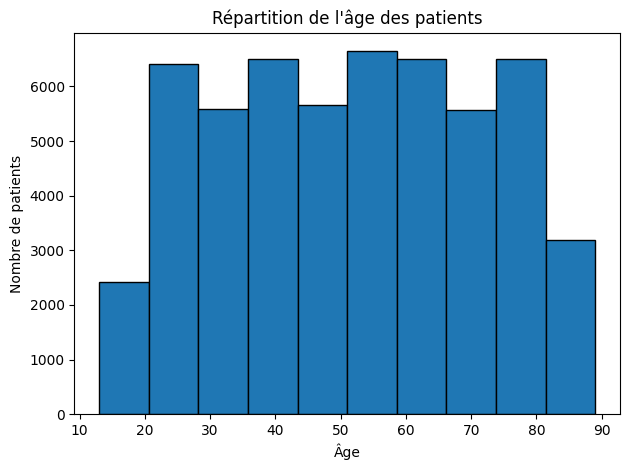

In [15]:
#Répartition de l'âge des patients

dataset["Age"].plot(
    kind="hist",
    bins=10,
    edgecolor="black"
)

plt.title("Répartition de l'âge des patients")
plt.xlabel("Âge")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

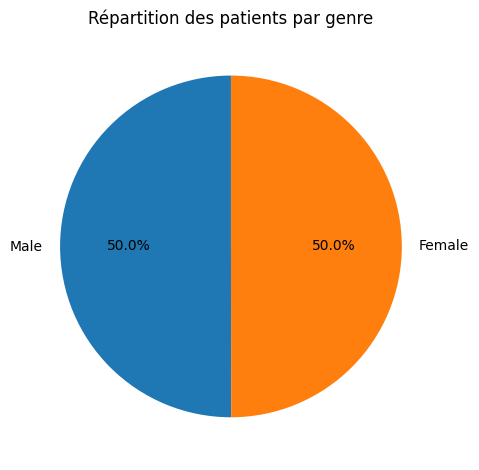

In [16]:
# Compter le nombre de patients par genre
repartition_genre = dataset["Gender"].value_counts()

# Créer le graphique en camembert
repartition_genre.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des patients par genre")
plt.ylabel("")  # Masquer le nom de la colonne sur le côté
plt.tight_layout()
plt.show()

# Insertion des données CSV dans la base de données Mongodb

## connexion a la base de données

In [ ]:

## Connexion avec Mongodb
client = MongoClient("mongodb://localhost:27017/")

print(client.list_database_names())


['admin', 'config', 'healtcare_db', 'local']


In [ ]:
# creation de la base de données
db = client["healtcare_db"]

# creation de la collection
collection = db["patients"]


## Tests de verification de la creation de la base de données mangoDB avec des Operation CRUD     

In [20]:
#insert 
#Name	Age	Gender	Blood Type	Medical Condition	Date of Admission	Doctor	Hospital	Insurance Provider	Billing Amount	Room Number	Admission Type	Discharge Date	Medication	Test Results

collection.insert_one({"nom":"Alice Dupont","Gender":"f","Blood Type":"o","Medical Condition":"rs","Date of Admission":"2004-10-10","Doctor":"ROZ","Hospital":"purp","Insurance Provider":"ll","Billing Amount":"1000","Room Number":"10","Admission Type":"VV","Discharge Date":"2010-11-11","Test Results":"negatif"})
collection.insert_one({"nom":"Reda","Gender":"f","Blood Type":"o","Medical Condition":"rs","Date of Admission":"2004-10-10","Doctor":"ROZ","Hospital":"purp","Insurance Provider":"ll","Billing Amount":"1000","Room Number":"10","Admission Type":"VV","Discharge Date":"2010-11-11","Test Results":"negatif"})

InsertOneResult(ObjectId('6a2c1532643650875df0a442'), acknowledged=True)

In [29]:
#Read
for patient in collection.find():
    print(patient)

{'_id': ObjectId('6a2ac95db5406bb85bfa3fbf'), 'nom': 'Alice Dupont', 'Gender': 'f', 'Blood Type': 'o', 'Medical Condition': 'rs', 'Date of Admission': '2004-10-10', 'Doctor': 'ROZ', 'Hospital': 'purp', 'Insurance Provider': 'll', 'Billing Amount': '1000', 'Room Number': '10', 'Admission Type': 'VV', 'Discharge Date': '2010-11-11', 'Test Results': 'negatif'}
{'_id': ObjectId('6a2acbf6b5406bb85bfa3fc0'), 'nom': 'Alice Dupont', 'Gender': 'f', 'Blood Type': 'o', 'Medical Condition': 'rs', 'Date of Admission': '2004-10-10', 'Doctor': 'ROZ', 'Hospital': 'purp', 'Insurance Provider': 'll', 'Billing Amount': '1000', 'Room Number': '10', 'Admission Type': 'VV', 'Discharge Date': '2010-11-11', 'Test Results': 'negatif'}
{'_id': ObjectId('6a2acbf6b5406bb85bfa3fc1'), 'nom': 'Reda', 'Gender': 'f', 'Blood Type': 'o', 'Medical Condition': 'rs', 'Date of Admission': '2004-10-10', 'Doctor': 'ROZ', 'Hospital': 'purp', 'Insurance Provider': 'll', 'Billing Amount': '1000', 'Room Number': '10', 'Admission 

In [21]:
#delete
collection.delete_many({})

DeleteResult({'n': 4, 'ok': 1.0}, acknowledged=True)

In [22]:
for patient in collection.find():
    print(patient)

In [ ]:
# Creation des documents


documents = dataset.to_dict(orient="records")

display(documents)

InsertManyResult([ObjectId('6a2c18d5643650875df0a443'), ObjectId('6a2c18d5643650875df0a444'), ObjectId('6a2c18d5643650875df0a445'), ObjectId('6a2c18d5643650875df0a446'), ObjectId('6a2c18d5643650875df0a447'), ObjectId('6a2c18d5643650875df0a448'), ObjectId('6a2c18d5643650875df0a449'), ObjectId('6a2c18d5643650875df0a44a'), ObjectId('6a2c18d5643650875df0a44b'), ObjectId('6a2c18d5643650875df0a44c'), ObjectId('6a2c18d5643650875df0a44d'), ObjectId('6a2c18d5643650875df0a44e'), ObjectId('6a2c18d5643650875df0a44f'), ObjectId('6a2c18d5643650875df0a450'), ObjectId('6a2c18d5643650875df0a451'), ObjectId('6a2c18d5643650875df0a452'), ObjectId('6a2c18d5643650875df0a453'), ObjectId('6a2c18d5643650875df0a454'), ObjectId('6a2c18d5643650875df0a455'), ObjectId('6a2c18d5643650875df0a456'), ObjectId('6a2c18d5643650875df0a457'), ObjectId('6a2c18d5643650875df0a458'), ObjectId('6a2c18d5643650875df0a459'), ObjectId('6a2c18d5643650875df0a45a'), ObjectId('6a2c18d5643650875df0a45b'), ObjectId('6a2c18d5643650875df0a4

In [ ]:
# Inserer les donner dans MongoDB

collection.insert_many(documents)

{'_id': ObjectId('6a2c18d5643650875df0a443'), 'Name': 'Bobby Jackson', 'Age': 30, 'Gender': 'Male', 'Blood Type': 'B-', 'Medical Condition': 'Cancer', 'Date of Admission': datetime.datetime(2024, 1, 31, 0, 0), 'Doctor': 'Matthew Smith', 'Hospital': 'Sons and Miller', 'Insurance Provider': 'Blue Cross', 'Billing Amount': 18856.281305978155, 'Room Number': 328, 'Admission Type': 'Urgent', 'Discharge Date': datetime.datetime(2024, 2, 2, 0, 0), 'Medication': 'Paracetamol', 'Test Results': 'Normal'}
{'_id': ObjectId('6a2c18d5643650875df0a4ac'), 'Name': 'Dwayne Davis', 'Age': 28, 'Gender': 'Male', 'Blood Type': 'O+', 'Medical Condition': 'Cancer', 'Date of Admission': datetime.datetime(2024, 1, 15, 0, 0), 'Doctor': 'Wendy Davis', 'Hospital': 'Ltd Thomas', 'Insurance Provider': 'Medicare', 'Billing Amount': 40782.92780848658, 'Room Number': 373, 'Admission Type': 'Elective', 'Discharge Date': datetime.datetime(2024, 2, 7, 0, 0), 'Medication': 'Ibuprofen', 'Test Results': 'Abnormal'}
{'_id': O

In [ ]:
#verification des insertions avec des operation crud
resultats = collection.find({
    "Date of Admission": {
        "$gte": datetime(2024, 1, 1),
        "$lt": datetime(2024, 2, 1)
    }
})

for i in resultats :
    print (i)